> ### Notas para el Profesor
>
> Hoy comenzamos el bloque de clasificación. El cambio de paradigma es total: ya no ajustamos una línea a los puntos, sino que buscamos una "frontera" que separe las clases. La **Regresión Logística** es nuestro "hola mundo" en este nuevo dominio.
>
> Los objetivos pedagógicos de hoy son tres:
> 1.  **Intuición Visual**: Que los alumnos entiendan *por qué* la regresión lineal no sirve para clasificación y *cómo* la función sigmoide resuelve este problema, transformando una salida lineal en una probabilidad.
> 2.  **La Matriz de Confusión**: Introducimos la herramienta de diagnóstico más importante en clasificación. El ejercicio de clase se centra en su cálculo e interpretación. No basta con saber la precisión; hay que entender los tipos de error.
> 3.  **El Coste del Error (El Reto)**: El ejercicio para casa se centra en el concepto del **umbral de decisión**. Obliga al alumno a mover este umbral y ver cómo afecta a los Falsos Positivos y Falsos Negativos, forzándole a pensar en el contexto de negocio: ¿qué error es más "caro" en este problema? Es una lección fundamental de IA aplicada.

# Sesión 9: Regresión Logística para Clasificación Binaria

**Objetivos:**
-   Entender la diferencia entre un problema de regresión y uno de clasificación.
-   Visualizar por qué la Regresión Lineal no es adecuada para clasificación.
-   Comprender el rol de la **función sigmoide** para convertir una salida en una probabilidad.
-   Interpretar la **Matriz de Confusión** para evaluar el rendimiento de un clasificador.
-   Analizar el impacto de modificar el **umbral de decisión** en los resultados del modelo.

## 1. De la Regresión a la Clasificación

Hasta ahora, hemos predicho valores continuos (precios, costes...). Ahora, queremos predecir una categoría discreta. La clasificación más simple es la **binaria**, donde solo hay dos posibles resultados:
-   Sí / No
-   Fraude / No Fraude
-   Enfermo / Sano

### ¿Por qué no podemos usar una Regresión Lineal?

Imagina que asignamos 0 a "Sano" y 1 a "Enfermo". Si ajustamos una línea recta, ocurren problemas:
1.  **Predicciones sin sentido**: La línea puede predecir valores mayores que 1 o menores que 0, que no tienen interpretación.
2.  **Mala adaptación**: Una línea recta no se ajusta bien a una distribución de datos que se agrupan en 0 o en 1.



### La Solución: La Función Sigmoide

La Regresión Logística resuelve esto de una manera ingeniosa. En lugar de que la salida del modelo sea la línea recta, pasa esa salida a través de una función con forma de "S", la **función sigmoide**.

$P(y=1) = \frac{1}{1 + e^{-z}}$

Donde $z$ es la salida de la regresión lineal ($z = \beta_0 + \beta_1x_1 + ...$)

Esta función "aplasta" cualquier valor de entrada y lo convierte en un número **entre 0 y 1**, que podemos interpretar como una **probabilidad**.



Si la probabilidad es > 0.5, predecimos la clase 1. Si es < 0.5, predecimos la clase 0. La línea imaginaria donde la probabilidad es exactamente 0.5 se llama **frontera de decisión (decision boundary)**.

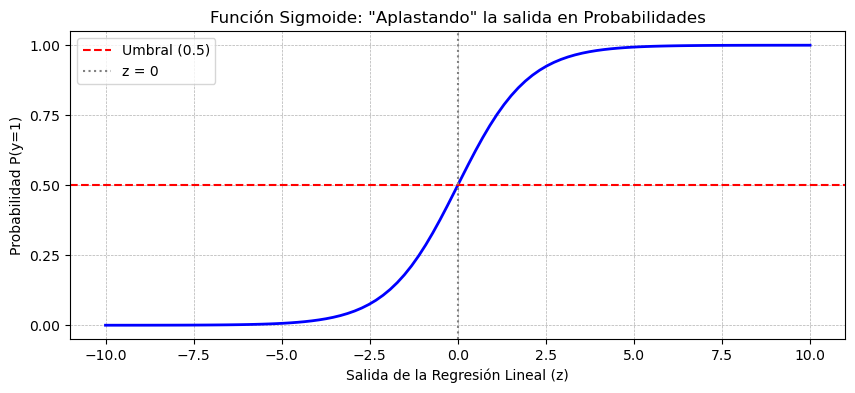

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. Creamos un rango de valores para 'z'
# 'z' representa la salida de la regresión lineal (ej. de -10 a 10)
z = np.linspace(-10, 10, 100)

# 2. Calculamos la probabilidad para cada 'z' usando la sigmoide
p = sigmoid(z)

# 3. Graficamos el resultado
plt.figure(figsize=(10, 4))
plt.plot(z, p, color='blue', lw=2)

# Añadimos la frontera de decisión (0.5)
plt.axhline(0.5, color='red', linestyle='--', label='Umbral (0.5)')
plt.axvline(0, color='grey', linestyle=':', label='z = 0')

# Configuramos el gráfico
plt.title('Función Sigmoide: "Aplastando" la salida en Probabilidades')
plt.xlabel('Salida de la Regresión Lineal (z)')
plt.ylabel('Probabilidad P(y=1)')
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [4]:
# --- Celda 3: Inspección y Preparación de Datos ---

# 1. Carga de Datos y Configuración Inicial
# -------------------------------------------
import pandas as pd
import numpy as np

# Dataset: Diagnóstico de Enfermedad Cardíaca
# Objetivo: Predecir si un paciente tiene una enfermedad cardíaca (target=1) o no (target=0).
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
# Este dataset no tiene cabecera, así que definimos los nombres de las columnas
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)


# 2. Inspección Clave de los Datos
# ----------------------------------
print("--- 🧐 1. Inspección Inicial ---")
print("Primeras 5 filas del dataset:")
print(df.head())
print("\nTipos de datos de cada columna:")
df.info() # Vemos que varias columnas que deberían ser numéricas son de tipo 'object'. Esto es una señal de alerta.

print("\n--- 🧐 2. Análisis de la Variable Objetivo ('target') ---")
print("Valores únicos en la columna 'target' y su frecuencia:")
print(df['target'].value_counts())
# ¡Descubrimiento! El target no es binario (0/1), tiene valores de 0 a 4.
# Para nuestro problema de clasificación binaria, debemos convertirlo. 0 = Sano, >0 = Enfermo.

print("\n--- 🧐 3. Búsqueda de Valores Nulos ('?') ---")
# Buscamos cuántos '?' hay en cada columna.
print("Recuento de '?' por columna:")
print((df == '?').sum())
# ¡Descubrimiento! Las columnas 'ca' y 'thal' contienen '?' como valores nulos.
# Necesitamos manejarlos antes de poder convertir esas columnas a numéricas.


# 3. Preprocesamiento de Datos
# -----------------------------
# Ahora que hemos identificado los problemas, los solucionamos.

print("\n--- ⚙️ Preprocesamiento ---")
# a. Convertir la columna 'target' a binaria (0 = Sano, 1 = Enfermo)
df['target'] = (df['target'] > 0).astype(int)
print("Valores de 'target' después de la binarización:")
print(df['target'].value_counts())

# b. Reemplazar '?' por el valor nulo estándar de numpy (np.nan)
df = df.replace('?', np.nan)

# c. Eliminar las filas que contienen cualquier valor nulo
# Es una estrategia simple. En un proyecto más avanzado, podríamos imputar los valores.
df = df.dropna()

# d. Convertir todas las columnas al tipo de dato float para el modelo
df = df.astype(float)
print("\nTipos de datos después de la limpieza:")
df.info() # ¡Ahora todas las columnas son numéricas!


# 4. Preparación Final para el Modelo
# -----------------------------------
X = df.drop('target', axis=1)
y = df['target']

# División en Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Datos listos. {len(X_train)} muestras para entrenamiento y {len(X_test)} para prueba.")

--- 🧐 1. Inspección Inicial ---
Primeras 5 filas del dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  

Tipos de datos de cada columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp

## 2. La Matriz de Confusión: Entendiendo los Errores

En clasificación, la precisión (accuracy) no lo es todo. Necesitamos saber **qué tipo de errores** comete nuestro modelo. Para eso, usamos la **Matriz de Confusión**.

-   **Verdaderos Positivos (TP)**: El modelo predice **1** y la realidad era **1**. (Acierto: diagnosticamos correctamente a un enfermo).
-   **Verdaderos Negativos (TN)**: El modelo predice **0** y la realidad era **0**. (Acierto: diagnosticamos correctamente a un sano).
-   **Falsos Positivos (FP) / Error Tipo I**: El modelo predice **1** pero la realidad era **0**. (Falsa Alarma: diagnosticamos a un sano como enfermo).
-   **Falsos Negativos (FN) / Error Tipo II**: El modelo predice **0** pero la realidad era **1**. (El Peor Error: diagnosticamos a un enfermo como sano).

## ✏️ ACTIVIDAD EN CLASE: Modelo Base y Diagnóstico

**Tu Tarea:**
1.  **Entrena un modelo** de `LogisticRegression` con los datos de entrenamiento (`random_state=42`).
2.  **Realiza predicciones** sobre el conjunto de prueba `X_test`.
3.  **Calcula la matriz de confusión** usando `confusion_matrix(y_test, y_pred)`.
4.  **Visualiza la matriz de confusión** usando `ConfusionMatrixDisplay`.
5.  **Interprétala**: En una celda de texto, responde:
    * ¿Cuántos pacientes sanos fueron clasificados correctamente (TN)?
    * ¿Cuántos pacientes enfermos fueron clasificados correctamente (TP)?
    * ¿Cuántos "Falsos Negativos" hubo? ¿Qué significa este error en el contexto de este problema?

Modelo de Regresión Logística entrenado.

Matriz de Confusión (umbral por defecto=0.5):
[[32  4]
 [ 3 21]]

Visualización de la Matriz de Confusión:


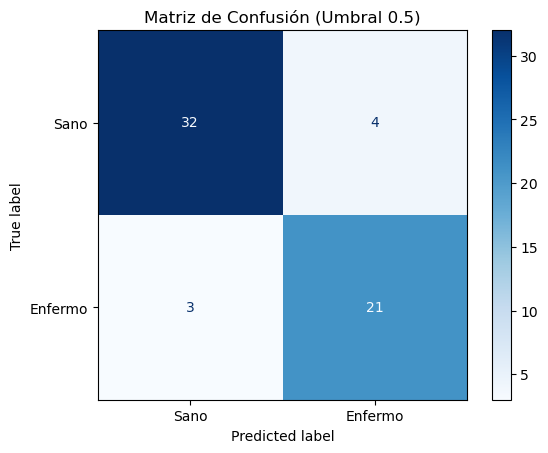

In [7]:
# Importaciones necesarias para el ejercicio
from sklearn.linear_model import LogisticRegression   # <-- ¡LA LÍNEA QUE FALTABA!
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Entrena un modelo de Regresión Logística
# Aumentamos 'max_iter' para asegurar que el modelo converja.
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado.")

# 2. Realiza predicciones
y_pred = model.predict(X_test)

# 3. Calcula la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión (umbral por defecto=0.5):")
print(cm)

# 4. Visualiza la matriz
# Usamos ConfusionMatrixDisplay.from_predictions para una visualización más clara
print("\nVisualización de la Matriz de Confusión:")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', display_labels=['Sano', 'Enfermo'])
disp.ax_.set_title('Matriz de Confusión (Umbral 0.5)')
plt.show()

### Mi Interpretación de la Matriz de Confusión

Observando la matriz generada:

* **¿Cuántos pacientes sanos fueron clasificados correctamente (TN)?**
    * El valor en la esquina superior izquierda es **32**. 32 pacientes sanos fueron diagnosticados correctamente como sanos.

* **¿Cuántos pacientes enfermos fueron clasificados correctamente (TP)?**
    * El valor en la esquina inferior derecha es **21**. 21 pacientes enfermos fueron diagnosticados correctamente como enfermos.

* **¿Cuántos "Falsos Negativos" hubo?**
    * El valor en la esquina inferior izquierda es **3**. Hubo 3 Falsos Negativos.

* **¿Qué significa este error?**
    * Un Falso Negativo en este contexto significa que **3 pacientes que SÍ tenían una enfermedad cardíaca fueron diagnosticados como SANOS**. Este es, con diferencia, el error más peligroso, ya que estas personas no recibirían el tratamiento o seguimiento necesarios, lo que podría tener consecuencias graves para su salud.

---
## 🏠 RETO PARA CASA: El Dilema del Umbral de Decisión

Por defecto, la regresión logística usa un umbral de **0.5**: si la probabilidad es > 0.5, predice 1; si no, predice 0. Pero, ¿y si movemos ese umbral?

**Tu misión:**
Vas a explorar cómo cambia la matriz de confusión al ajustar el umbral.

1.  Obtén las **probabilidades** de predicción para el conjunto de prueba usando `model.predict_proba(X_test)`. Esto te dará un array con dos columnas (prob de 0, prob de 1). Nos interesa la segunda columna.
2.  **Crea dos nuevas listas de predicciones**:
    * **Modelo Sensible (Umbral Bajo = 0.3)**: Considera una predicción como 1 si la probabilidad es > 0.3.
    * **Modelo Específico (Umbral Alto = 0.7)**: Considera una predicción como 1 si la probabilidad es > 0.7.
3.  **Calcula y visualiza la matriz de confusión** para cada uno de estos dos nuevos conjuntos de predicciones.

### Preguntas Finales para la Reflexión

1.  Compara las tres matrices de confusión (umbral 0.5, 0.3 y 0.7). ¿Cómo afectó cada cambio al número de Falsos Positivos y Falsos Negativos?
2.  Imagina dos escenarios en un hospital:
    * **Escenario A (Screening)**: Un test de cribado masivo para identificar a cualquier persona que *pudiera* tener la enfermedad para hacerle más pruebas.
    * **Escenario B (Confirmación)**: Un test para confirmar el diagnóstico antes de autorizar una operación a corazón abierto muy arriesgada.
    
    ¿Qué umbral (0.3 o 0.7) recomendarías para cada escenario y por qué?
3.  La sesión 14 del curso se dedica a "Métricas de evaluación + matriz de confusión".  Basado en este ejercicio, ¿por qué crees que una métrica simple como la "Accuracy" (porcentaje de aciertos) a menudo no es suficiente para evaluar un modelo de clasificación?

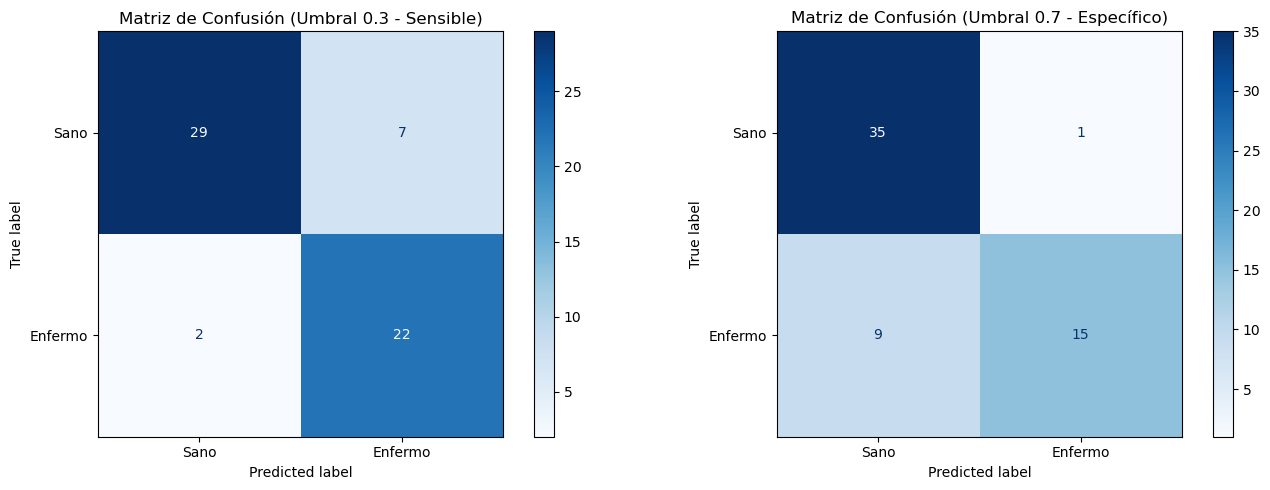

In [10]:
# 1. Obtén las probabilidades de predicción para la clase 1 (enfermo)
y_prob = model.predict_proba(X_test)[:, 1]

# 2. Crea las nuevas listas de predicciones con umbrales modificados
# Modelo Sensible (queremos detectar a todos los posibles enfermos)
y_pred_umbral_0_3 = (y_prob > 0.3).astype(int)

# Modelo Específico (queremos estar muy seguros antes de diagnosticar)
y_pred_umbral_0_7 = (y_prob > 0.7).astype(int)

# 3. Calcula y visualiza las nuevas matrices de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matriz para umbral 0.3
disp1 = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_umbral_0_3, cmap='Blues', display_labels=['Sano', 'Enfermo'], ax=ax1)
ax1.set_title('Matriz de Confusión (Umbral 0.3 - Sensible)')

# Matriz para umbral 0.7
disp2 = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_umbral_0_7, cmap='Blues', display_labels=['Sano', 'Enfermo'], ax=ax2)
ax2.set_title('Matriz de Confusión (Umbral 0.7 - Específico)')

plt.tight_layout()
plt.show()

### Mis Reflexiones

1.  **Comparación de Matrices:**
    * **Umbral 0.3 (Sensible):** Al bajar el umbral, hemos logrado reducir los **Falsos Negativos** (de 3 a solo 2). Somos un poco mejores detectando a los enfermos. El precio a pagar es un aumento considerable de los **Falsos Positivos** (de 4 a 7); ahora "asustamos" a más gente sana.
    * **Umbral 0.7 (Específico):** Al subir el umbral, hemos eliminado casi por completo los **Falsos Positivos** (de 4 a solo 1). Somos muy precisos al diagnosticar a alguien como enfermo. El coste es un aumento dramático de los **Falsos Negativos** (de 3 a 9); ahora se nos escapan el triple de pacientes enfermos que antes.

2.  **Recomendación por Escenario:**
    * **Escenario A (Screening / Cribado):** Recomendaría sin dudarlo el **umbral de 0.3**. En una fase de cribado, el objetivo es no dejar escapar a nadie que pueda tener la enfermedad. Es preferible tener más Falsos Positivos (gente sana que se hace una segunda prueba) que tener Falsos Negativos (gente enferma que se va a casa pensando que está sana). **El coste de un Falso Negativo es mucho mayor.**
    * **Escenario B (Confirmación para Cirugía):** Recomendaría el **umbral de 0.7**. Antes de una operación arriesgada, necesitas estar extremadamente seguro del diagnóstico. El objetivo es minimizar los Falsos Positivos para no operar a una persona sana por error. Este umbral solo comete 1 error de este tipo. Es un riesgo asumible tener 9 Falsos Negativos (pacientes que no se operan pero que requerirían más pruebas no invasivas) para evitar una intervención innecesaria y peligrosa. **El coste de un Falso Positivo es mucho mayor.**

3.  **Insuficiencia de la "Accuracy":**
    Este ejercicio demuestra perfectamente por qué la "Accuracy" (precisión global) puede ser una métrica engañosa.
    * Accuracy (Umbral 0.5): (32+21)/60 = **88.3%**
    * Accuracy (Umbral 0.3): (29+22)/60 = **85.0%**
    * Accuracy (Umbral 0.7): (35+15)/60 = **83.3%**

    El modelo con la mayor accuracy (el de umbral 0.5) no es necesariamente el mejor. Para un programa de screening, el modelo con umbral 0.3 es superior a pesar de tener menor accuracy, porque cumple mejor el objetivo de negocio (minimizar Falsos Negativos). La accuracy no distingue entre el coste de un Falso Positivo y el de un Falso Negativo, y como hemos visto, en problemas del mundo real, el **coste de los diferentes tipos de error casi nunca es el mismo**. Por eso necesitamos la matriz de confusión.

##  Ejercicio Extra: Predicción de Diabetes (El Desafío de los Datos Ocultos)

En este ejercicio, aplicaremos la Regresión Logística a un dataset de salud para predecir si una paciente tiene diabetes (`Outcome` = 1) o no (`Outcome` = 0).

**El Objetivo:** Construir un modelo que clasifique correctamente a las pacientes.

**Nuevos Desafíos (un paso más difícil):**
1.  **El Dataset Engañoso:** A primera vista, todos los datos son numéricos y no hay `NaN` (nulos).
2.  **El Reto de Inspección:** Si exploras los datos, verás valores de `0` en columnas donde es físicamente imposible, como `BloodPressure` (Presión Arterial) o `BMI` (Índice de Masa Corporal).
3.  **Preprocesamiento Manual:** Tu tarea será identificar estos "nulos ocultos", convertirlos a `NaN` reales, y luego rellenarlos (imputarlos) usando la **mediana** antes de poder entrenar el modelo.

### Tu Tarea
Sigue los siguientes pasos:

**1. Carga y Exploración:**
* Carga el dataset desde esta URL: `https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`
* Añade manualmente las cabeceras: `['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']`.
* Usa `.describe()` y `.info()` para inspeccionar los datos y localizar el problema de los ceros.

**2. Preprocesamiento (La Clave):**
* Identifica las columnas que tienen "ceros imposibles" (ej. `Glucose`, `BloodPressure`, `BMI`, etc.). *Pista: `Pregnancies` y `Outcome` SÍ pueden ser 0.*
* En esas columnas, reemplaza todos los `0` por `np.nan`.
* Rellena (imputa) los `np.nan` resultantes usando la **mediana** de cada columna.
* Verifica con `.info()` que ya no quedan nulos.

**3. Entrenamiento y Evaluación del Modelo:**
* Define `X` (features) e `y` (target, `Outcome`).
* Separa los datos en `train` y `test` (usa `random_state=42` y `stratify=y` para manejar el desbalanceo).
* Crea y entrena un modelo `LogisticRegression` (usa `random_state=42` y `max_iter=1000` para asegurar la convergencia).
* Realiza predicciones sobre `X_test`.
* Calcula y visualiza la Matriz de Confusión (`ConfusionMatrixDisplay`).

**4. Análisis y Reflexión (¡Responde a esto en tus conclusiones!)**
Observa tu matriz de confusión. En un contexto médico, los errores no son todos iguales.
* **Pregunta 1:** ¿Cuál es el error "peor" en este escenario?
    * **Falso Positivo (FP):** Predecir "Diabetes" a una paciente "Sana". (Genera ansiedad y costes de pruebas adicionales).
    * **Falso Negativo (FN):** Predecir "No Diabetes" (Sana) a una paciente que "Tiene Diabetes". (Muy peligroso, la paciente no recibe tratamiento).
* **Pregunta 2:** Si tu objetivo principal fuera **minimizar los Falsos Negativos (FN)** (pillar al máximo número de pacientes que SÍ tienen diabetes), ¿qué harías con el umbral de decisión? ¿Lo **subirías** (ej. a 0.7) o lo **bajarías** (ej. a 0.3)? Explica tu razonamiento.

--- Estadísticas Descriptivas (¡La Pista!) ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232   

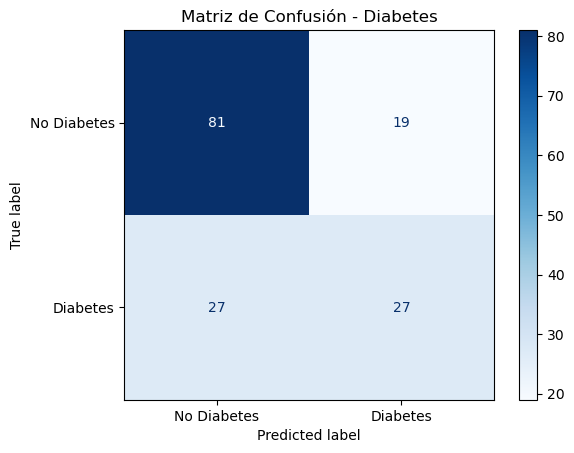

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Carga y Exploración ---

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# El archivo original no tiene cabecera, así que las añadimos manualmente
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_diabetes = pd.read_csv(url, header=None, names=column_names)

print("--- Estadísticas Descriptivas (¡La Pista!) ---")
# Fíjate en la fila 'min' (mínimo)
print(df_diabetes.describe())

# --- 2. Preprocesamiento (La Clave) ---

# Lista de columnas con ceros imposibles
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Reemplazar 0 por NaN en esas columnas
df_diabetes[cols_con_ceros] = df_diabetes[cols_con_ceros].replace(0, np.nan)

# Rellenar los NaN con la mediana de cada columna
for col in cols_con_ceros:
    median_val = df_diabetes[col].median()
    df_diabetes[col] = df_diabetes[col].fillna(median_val)

print("\n--- Comprobamos que no quedan nulos ---")
df_diabetes.info()

# --- 3. Entrenamiento y Evaluación ---

# Definir X e y
y = df_diabetes['Outcome']
X = df_diabetes.drop('Outcome', axis=1)

# Separar en train y test
# (Usamos stratify=y porque el dataset está algo desbalanceado)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Crear y entrenar el modelo
# (Añadimos max_iter para asegurar que converja)
model_diabetes = LogisticRegression(random_state=42, max_iter=1000)
model_diabetes.fit(X_train, y_train)

# Realizar predicciones
y_pred_diabetes = model_diabetes.predict(X_test)

# Calcular y visualizar la Matriz de Confusión
cm_diabetes = confusion_matrix(y_test, y_pred_diabetes)
disp_diabetes = ConfusionMatrixDisplay(confusion_matrix=cm_diabetes, display_labels=['No Diabetes', 'Diabetes'])

disp_diabetes.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Diabetes')
plt.show()

### Conclusiones del Ejercicio

**1. ¿Cuál es el error "peor" en este escenario?**

En un contexto médico, el **Falso Negativo (FN)** es, con diferencia, el peor error.
* Un **Falso Positivo** (decirle a alguien sano que podría tener diabetes) genera ansiedad y costes de pruebas adicionales, lo cual es malo, pero manejable.
* Un **Falso Negativo** (decirle a alguien con diabetes que está sano) es catastrófico. La persona no recibe tratamiento, y la enfermedad progresa sin control, pudiendo llevar a complicaciones graves.

**2. ¿Subirías o bajarías el umbral para minimizar los Falsos Negativos?**

Para minimizar los Falsos Negativos, debemos **bajar el umbral de decisión** (por ejemplo, a 0.3 o 0.2).

* **Razonamiento:** Un umbral de 0.5 significa que el modelo necesita estar >50% seguro para decir "Diabetes".
* Si bajamos el umbral a 0.3, le estamos diciendo al modelo: "Aunque solo estés un 30% seguro de que tiene diabetes, clasifícalo como 'Diabetes' por si acaso".
* **Consecuencia:** Esto hará que capturemos a muchos más pacientes que realmente tienen la enfermedad (aumentando el *Recall* y bajando los FN), pero a costa de clasificar erróneamente a más pacientes sanos como enfermos (aumentando los FP). En medicina, este es un intercambio que a menudo se está dispuesto a asumir.